In [6]:
import sys
print(sys.executable)

d:\GÓI 1\chủ đề 3 - tuần 4\market-risk-measurement\.venv\Scripts\python.exe


In [28]:
import os
import sys
from pathlib import Path

# ============================================================
# PROJECT SETUP
# Hỗ trợ chạy trên VS Code và Google Colab
# ============================================================

if "google.colab" in sys.modules:
    # Chạy trên Google Colab
    import subprocess

    REPO_URL = "https://github.com/pnga1206/market-risk-measurement.git"
    REPO_NAME = "market-risk-measurement"

    if not Path(f"/content/{REPO_NAME}").exists():
        subprocess.run(
            ["git", "clone", REPO_URL, f"/content/{REPO_NAME}"],
            check=True
        )

    ROOT = Path(f"/content/{REPO_NAME}")

else:
    # Chạy trên VS Code/Jupyter local
    ROOT = Path.cwd()

    # Nếu Notebook được chạy từ thư mục notebooks/
    if ROOT.name == "notebooks":
        ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Project root:", ROOT)
print("Python:", sys.executable)

Project root: d:\GÓI 1\chủ đề 3 - tuần 4\market-risk-measurement
Python: d:\GÓI 1\chủ đề 3 - tuần 4\market-risk-measurement\.venv\Scripts\python.exe


In [29]:
from pathlib import Path

DATA_DIR = Path(ROOT) / "data" / "main"

print("Data folder:", DATA_DIR)
print("\nFiles:")
for file in DATA_DIR.iterdir():
    print("-", file.name)

Data folder: d:\GÓI 1\chủ đề 3 - tuần 4\market-risk-measurement\data\main

Files:
- fx_raw.csv
- portfolio_aligned.csv
- portfolio_returns.csv
- sp500_raw.csv
- vnindex_raw.csv


In [9]:
vn = pd.read_csv(DATA_DIR / "vnindex_raw.csv")
sp = pd.read_csv(DATA_DIR / "sp500_raw.csv")
fx = pd.read_csv(DATA_DIR / "fx_raw.csv")

print("VN-Index:")
print(vn.head())
print("\nColumns:", vn.columns.tolist())

print("\nS&P 500:")
print(sp.head())
print("\nColumns:", sp.columns.tolist())

print("\nUSD/VND:")
print(fx.head())
print("\nColumns:", fx.columns.tolist())

VN-Index:
         date    open    high     low   close     volume
0  2016-01-04  579.03  579.97  573.15  574.41   95930580
1  2016-01-05  571.66  575.40  569.26  569.94   97997540
2  2016-01-06  569.50  574.57  569.50  574.57   82285160
3  2016-01-07  570.62  570.94  561.09  565.36  140610960
4  2016-01-08  562.62  563.17  556.36  560.05  133652640

Columns: ['date', 'open', 'high', 'low', 'close', 'volume']

S&P 500:
         date    close
0  2016-09-26  2146.10
1  2016-09-27  2159.93
2  2016-09-28  2171.37
3  2016-09-29  2151.13
4  2016-09-30  2168.27

Columns: ['date', 'close']

USD/VND:
         date    close
0  2016-01-01  22180.0
1  2016-01-04  22320.0
2  2016-01-05  22141.0
3  2016-01-06  22034.0
4  2016-01-07  22014.0

Columns: ['date', 'close']


In [10]:
portfolio = pd.read_csv(DATA_DIR / "portfolio_aligned.csv")
returns = pd.read_csv(DATA_DIR / "portfolio_returns.csv")

print("PORTFOLIO ALIGNED")
print(portfolio.head())
print("\nColumns:", portfolio.columns.tolist())
print("Shape:", portfolio.shape)

print("\nPORTFOLIO RETURNS")
print(returns.head())
print("\nColumns:", returns.columns.tolist())
print("Shape:", returns.shape)

PORTFOLIO ALIGNED
         date  vnindex_close  sp500_close_usd  usd_vnd  sp500_close_vnd
0  2016-09-26         677.04          2146.10  21940.0      47085434.00
1  2016-09-27         684.89          2159.93  22018.0      47557338.74
2  2016-09-28         686.72          2171.37  21956.0      47674599.72
3  2016-09-29         688.55          2151.13  21945.0      47206547.85
4  2016-09-30         686.00          2168.27  21797.0      47261781.19

Columns: ['date', 'vnindex_close', 'sp500_close_usd', 'usd_vnd', 'sp500_close_vnd']
Shape: (2383, 5)

PORTFOLIO RETURNS
         date  vnindex_close  sp500_close_usd  usd_vnd  sp500_close_vnd  \
0  2016-09-27         684.89          2159.93  22018.0      47557338.74   
1  2016-09-28         686.72          2171.37  21956.0      47674599.72   
2  2016-09-29         688.55          2151.13  21945.0      47206547.85   
3  2016-09-30         686.00          2168.27  21797.0      47261781.19   
4  2016-10-03         683.05          2161.20  22004.0

In [11]:
print("Missing values:")
print(returns.isna().sum())

print("\nDuplicate dates:", returns["date"].duplicated().sum())

print("\nPortfolio return statistics:")
print(returns["portfolio_return"].describe())

print("\nDate range:")
print(returns["date"].min(), "→", returns["date"].max())

Missing values:
date                0
vnindex_close       0
sp500_close_usd     0
usd_vnd             0
sp500_close_vnd     0
vnindex_return      0
sp500_vnd_return    0
portfolio_return    0
dtype: int64

Duplicate dates: 0

Portfolio return statistics:
count    2382.000000
mean        0.000506
std         0.009099
min        -0.076614
25%        -0.003535
50%         0.001056
75%         0.005370
max         0.058284
Name: portfolio_return, dtype: float64

Date range:
2016-09-27 → 2026-09-24


In [12]:
# Chuẩn bị chuỗi lợi suất cho mô hình VaR
portfolio_returns = returns.copy()

portfolio_returns["date"] = pd.to_datetime(portfolio_returns["date"])

portfolio_return_series = (
    portfolio_returns
    .set_index("date")["portfolio_return"]
    .dropna()
)

print("Số quan sát:", len(portfolio_return_series))
print("Từ:", portfolio_return_series.index.min())
print("Đến:", portfolio_return_series.index.max())
print("\n5 quan sát đầu:")
print(portfolio_return_series.head())

Số quan sát: 2382
Từ: 2016-09-27 00:00:00
Đến: 2026-09-24 00:00:00

5 quan sát đầu:
date
2016-09-27    0.010750
2016-09-28    0.002566
2016-09-29   -0.003602
2016-09-30   -0.001270
2016-10-03    0.000938
Name: portfolio_return, dtype: float64


In [13]:
from src.var.var_models import (
    calculate_historical_var,
    calculate_parametric_var,
    calculate_monte_carlo_var
)

CONF_LEVEL = 0.975

var_historical = calculate_historical_var(
    portfolio_return_series,
    conf_level=CONF_LEVEL
)

var_parametric = calculate_parametric_var(
    portfolio_return_series,
    conf_level=CONF_LEVEL
)

var_monte_carlo = calculate_monte_carlo_var(
    portfolio_return_series,
    conf_level=CONF_LEVEL
)

var_results = pd.DataFrame({
    "Phương pháp": [
        "Historical",
        "Parametric",
        "Monte Carlo"
    ],
    "VaR 97.5%": [
        var_historical,
        var_parametric,
        var_monte_carlo
    ]
})

var_results["VaR 97.5% (%)"] = var_results["VaR 97.5%"] * 100

var_results

,Phương pháp,VaR 97.5%,VaR 97.5% (%)
0,Historical,0.019427,1.942651
1,Parametric,0.017328,1.732783
2,Monte Carlo,0.017406,1.740564


In [14]:
from src.var.var_models import run_rolling_var

rolling_var = run_rolling_var(
    portfolio_return_series,
    window=250,
    conf_level=0.975
)

print("Shape:", rolling_var.shape)
print("\n5 dòng đầu:")
print(rolling_var.head())

print("\n5 dòng cuối:")
print(rolling_var.tail())

Shape: (2132, 3)

5 dòng đầu:
            VaR_Historical  VaR_Parametric  VaR_MonteCarlo
Date                                                      
2017-10-05        0.009503        0.009302        0.009272
2017-10-06        0.009503        0.009259        0.009262
2017-10-09        0.009503        0.009275        0.009351
2017-10-10        0.009503        0.009243        0.009239
2017-10-11        0.009503        0.009232        0.009287

5 dòng cuối:
            VaR_Historical  VaR_Parametric  VaR_MonteCarlo
Date                                                      
2026-09-18        0.015483        0.014803        0.015021
2026-09-21        0.015483        0.014805        0.014862
2026-09-22        0.015483        0.014695        0.014400
2026-09-23        0.015483        0.014564        0.014734
2026-09-24        0.015483        0.014645        0.014833


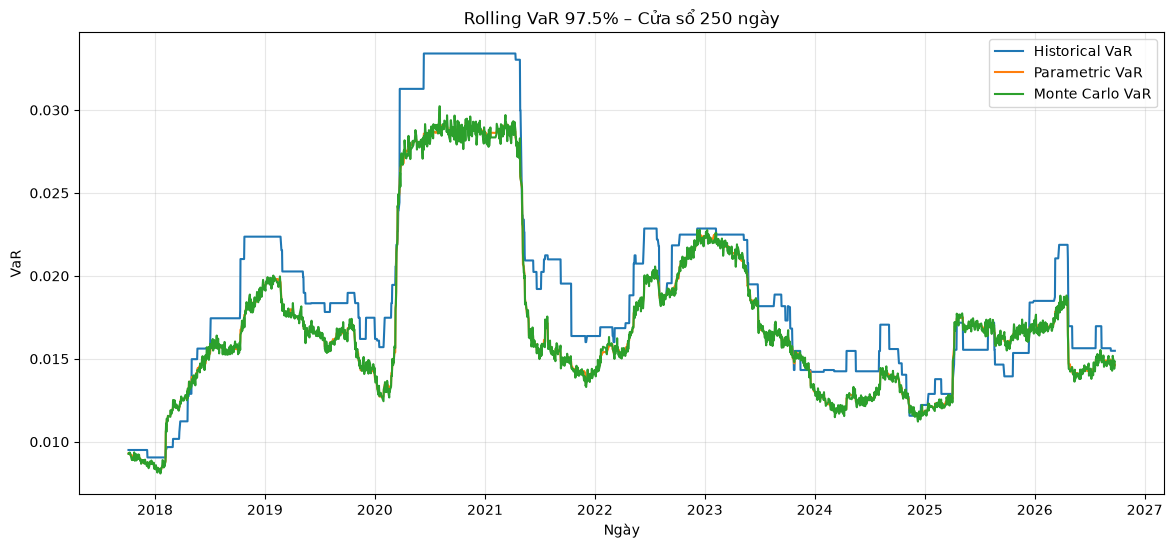

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    rolling_var.index,
    rolling_var["VaR_Historical"],
    label="Historical VaR"
)

plt.plot(
    rolling_var.index,
    rolling_var["VaR_Parametric"],
    label="Parametric VaR"
)

plt.plot(
    rolling_var.index,
    rolling_var["VaR_MonteCarlo"],
    label="Monte Carlo VaR"
)

plt.title("Rolling VaR 97.5% – Cửa sổ 250 ngày")
plt.xlabel("Ngày")
plt.ylabel("VaR")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [16]:
OUTPUT_TABLES = Path(ROOT) / "outputs" / "tables"
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)

rolling_var.to_csv(
    OUTPUT_TABLES / "rolling_var_975.csv"
)

print("Đã lưu:", OUTPUT_TABLES / "rolling_var_975.csv")

Đã lưu: d:\GÓI 1\chủ đề 3 - tuần 4\market-risk-measurement\outputs\tables\rolling_var_975.csv


In [17]:
print(rolling_var.describe())

       VaR_Historical  VaR_Parametric  VaR_MonteCarlo
count     2132.000000     2132.000000     2132.000000
mean         0.019017        0.017200        0.017175
std          0.006010        0.004965        0.004957
min          0.009054        0.008315        0.008086
25%          0.015475        0.014207        0.014114
50%          0.017477        0.016181        0.016132
75%          0.021840        0.018627        0.018661
max          0.033408        0.029252        0.030228


In [18]:
import arch

print("arch version:", arch.__version__)

arch version: 8.0.0


In [19]:
from src.garch.garch_model import calculate_garch_var_es_rolling

In [20]:
garch_results = calculate_garch_var_es_rolling(
    portfolio_return_series,
    window=250,
    conf_level=0.975
)

print("Shape:", garch_results.shape)
display(garch_results.head())
display(garch_results.tail())

Shape: (2132, 3)


,GARCH_Volatility,VaR_GARCH,ES_97_5
Date,,,
2017-10-05,0.005064,0.009182,0.011096
2017-10-06,0.005022,0.009128,0.011025
2017-10-09,0.005011,0.009122,0.011015
2017-10-10,0.004985,0.009047,0.010930
2017-10-11,0.004966,0.008999,0.010875


,GARCH_Volatility,VaR_GARCH,ES_97_5
Date,,,
2026-09-18,0.007040,0.013325,0.015985
2026-09-21,0.006833,0.012973,0.015555
2026-09-22,0.006686,0.012618,0.015144
2026-09-23,0.006598,0.012314,0.014807
2026-09-24,0.006900,0.012989,0.015596


In [21]:
OUTPUT_TABLES = Path(ROOT) / "outputs" / "tables"
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)

garch_results.to_csv(
    OUTPUT_TABLES / "garch_var_es_rolling_975.csv"
)

print("Đã lưu:", OUTPUT_TABLES / "garch_var_es_rolling_975.csv")

Đã lưu: d:\GÓI 1\chủ đề 3 - tuần 4\market-risk-measurement\outputs\tables\garch_var_es_rolling_975.csv


In [22]:
garch_results.describe()

,GARCH_Volatility,VaR_GARCH,ES_97_5
count,2132.000000,2132.000000,2132.000000
mean,0.008691,0.016172,0.019456
std,0.004232,0.008407,0.010003
min,0.004015,0.006773,0.008290
25%,0.006657,0.012123,0.014665
50%,0.007710,0.014090,0.016994
75%,0.009563,0.018031,0.021671
max,0.063117,0.123312,0.147160


In [23]:
garch_results.loc[
    garch_results["VaR_GARCH"].nlargest(10).index
]

,GARCH_Volatility,VaR_GARCH,ES_97_5
Date,,,
2020-03-17,0.063117,0.123312,0.147160
2020-03-13,0.062602,0.122284,0.145937
2020-03-10,0.050513,0.098621,0.117707
2020-03-16,0.049903,0.097417,0.116272
2020-03-18,0.046643,0.091021,0.108645
2020-03-24,0.040554,0.079209,0.094532
2020-03-25,0.039842,0.077840,0.092894
2020-03-12,0.038873,0.075728,0.090416
2020-03-11,0.038640,0.075326,0.089926


In [24]:
garch_results["VaR_GARCH"].nlargest(10)

Date
2020-03-17    0.123312
2020-03-13    0.122284
2020-03-10    0.098621
2020-03-16    0.097417
2020-03-18    0.091021
2020-03-24    0.079209
2020-03-25    0.077840
2020-03-12    0.075728
2020-03-11    0.075326
2020-03-19    0.070721
Name: VaR_GARCH, dtype: float64

In [25]:
OUTPUT_TABLES = Path(ROOT) / "outputs" / "tables"

garch_results.to_csv(
    OUTPUT_TABLES / "garch_var_es_rolling_975.csv"
)

print("Đã lưu:", OUTPUT_TABLES / "garch_var_es_rolling_975.csv")

Đã lưu: d:\GÓI 1\chủ đề 3 - tuần 4\market-risk-measurement\outputs\tables\garch_var_es_rolling_975.csv


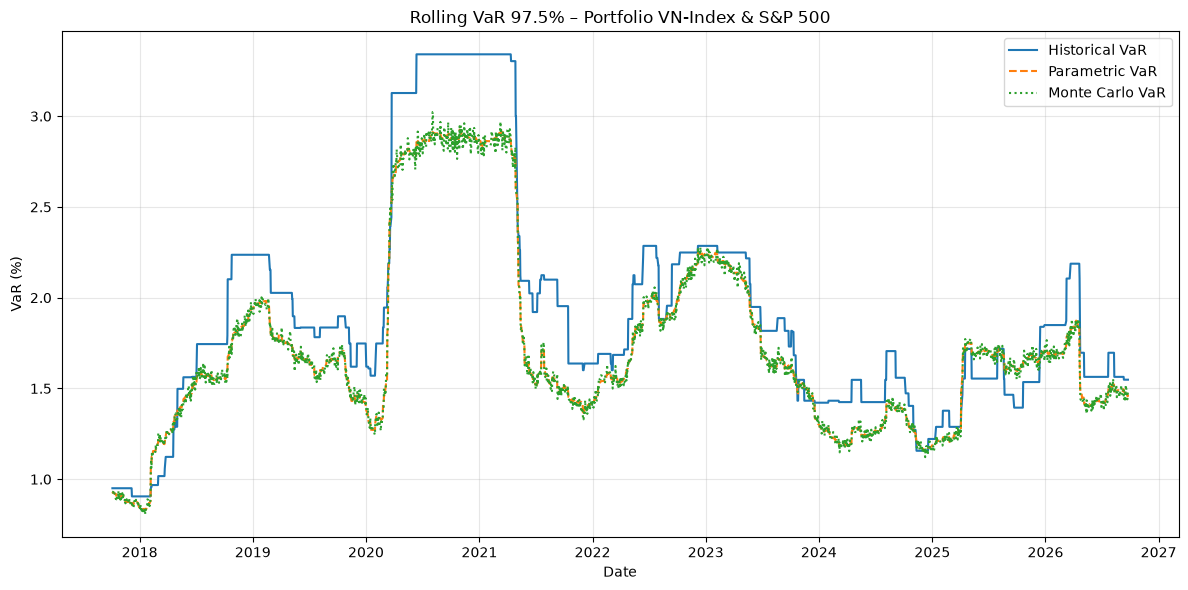

Đã lưu: d:\GÓI 1\chủ đề 3 - tuần 4\market-risk-measurement\outputs\figures\rolling_var_975.png


In [27]:
import matplotlib.pyplot as plt

OUTPUT_FIGURES = Path(ROOT) / "outputs" / "figures"
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 6))

plt.plot(
    rolling_var.index,
    rolling_var["VaR_Historical"] * 100,
    label="Historical VaR",
    linestyle="-"
)

plt.plot(
    rolling_var.index,
    rolling_var["VaR_Parametric"] * 100,
    label="Parametric VaR",
    linestyle="--"
)

plt.plot(
    rolling_var.index,
    rolling_var["VaR_MonteCarlo"] * 100,
    label="Monte Carlo VaR",
    linestyle=":"
)

plt.title("Rolling VaR 97.5% – Portfolio VN-Index & S&P 500")
plt.xlabel("Date")
plt.ylabel("VaR (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

figure_path = OUTPUT_FIGURES / "rolling_var_975.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu:", figure_path)